# <center>**IROS**<center>

**Libraries**

In [3]:
from pathlib import Path
import numpy as np
import mbloodmoon.iros_management as iros
import mbloodmoon as bm

from IROS_pipeline import _handle_dirpaths

In [4]:
mask_FITS = "wfm_mask.fits"

skyfield = "GalacticCenter"
data_FITS = "20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb"

_, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
)

cam_a = "cam1a"
cam_b = "cam1b"
#dataset = "reconstructed"

filepaths = bm.simulation_files(simul_data)
#sdlA = bm.simulation(filepaths[cam_a][dataset])
#sdlB = bm.simulation(filepaths[cam_b][dataset])

catalogA = bm.simulation(filepaths[cam_a]["sources"])
catalogB = bm.simulation(filepaths[cam_b]["sources"])

N_TEST = "6_NORMALMASK"

In [4]:
simul_data, save_path

('/media/egiancarli/Data/Edos_Magnificent_Manor/PhD_AASS/Coding/Data/Simulations/GalacticCenter/20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb/',
 '/media/egiancarli/Data/Edos_Magnificent_Manor/PhD_AASS/Coding/Data/Outputs/GalacticCenter/20241011_galctr_rxte_sax_2-30keV_1ks_2cams_sources_cxb/')

In [8]:
database_name = root_path + f"IROS_sources_database_TEST{N_TEST}.fits"
database = iros.load_iros_data(database_name)

# Loading data...
# Loading completed!


- Scatter plot with RA and DEC residues

In [9]:
database["cam1a"]["catalog_name"]["data"], database["cam1b"]["catalog_name"]["data"]

(chararray(['scox1', 'gx5-1', 'gx349+2', 'gx17+2', 'gx9+1', 'gx340+0',
            'gx3+1', 'gx13+1', 'x1820-303', 'cirx1', 'gx9+9',
            'groj1655-40', 'grs1915+105', 'x1735-444', 'x1636-536',
            'serx1', 'gx354-0'], dtype='<U20'),
 chararray(['scox1', 'gx5-1', 'gx349+2', 'gx17+2', 'gx9+1', 'gx340+0',
            'gx3+1', 'gx13+1', 'x1820-303', 'cirx1', 'gx9+9',
            'groj1655-40', 'grs1915+105', 'x1705-440', 'x1636-536',
            'serx1', 'gx354-0'], dtype='<U20'))

In [10]:
#res_df

# Checking CAM1A...
# Checking CAM1B...


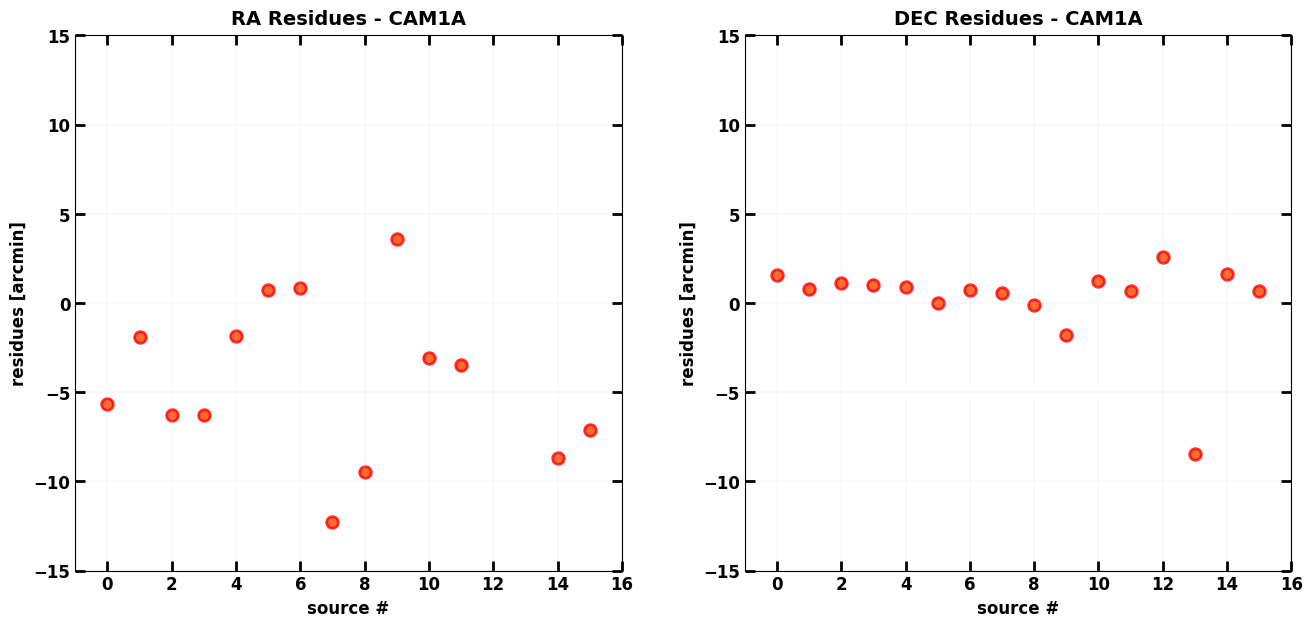

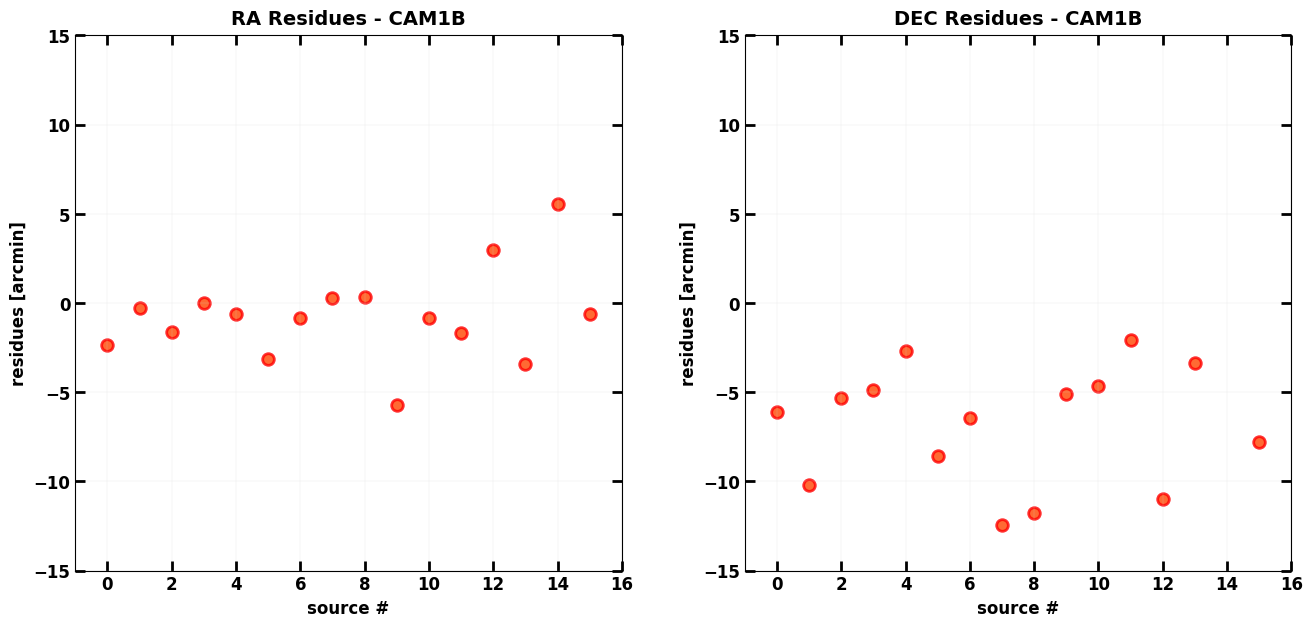

In [11]:
res_df = iros.check_sources_res(database, (catalogA, catalogB))
res_df = res_df.drop(index=13)

for cameraID in (cam_a, cam_b):
    iros.plot_sequence(
        input_sequence=[60*res_df[cameraID]["ra_res"], 60*res_df[cameraID]["dec_res"]],
        title=[e + f" Residues - {cameraID.upper()}" for e in ["RA", "DEC"]],
        xlabel=[r"source #"]*2,
        ylabel=["residues [arcmin]"]*2,
        style=["scatter"]*2,
        offsetx=[(-1, len(res_df[cameraID]["ra_res"]))]*2,
        offsety=[(-15, 15)]*2,
    )

- Scatter plot with RA residues vs off-axis angle $\theta_{y}$, DEC residues vs off-axis angle $\theta_{x}$

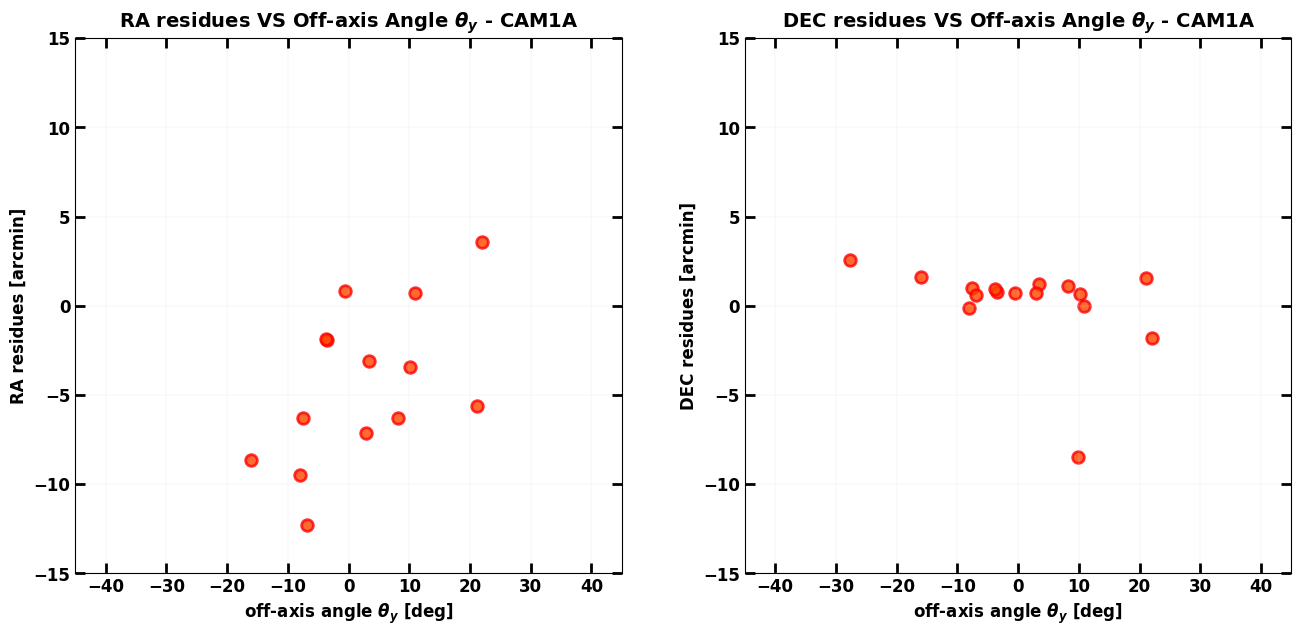

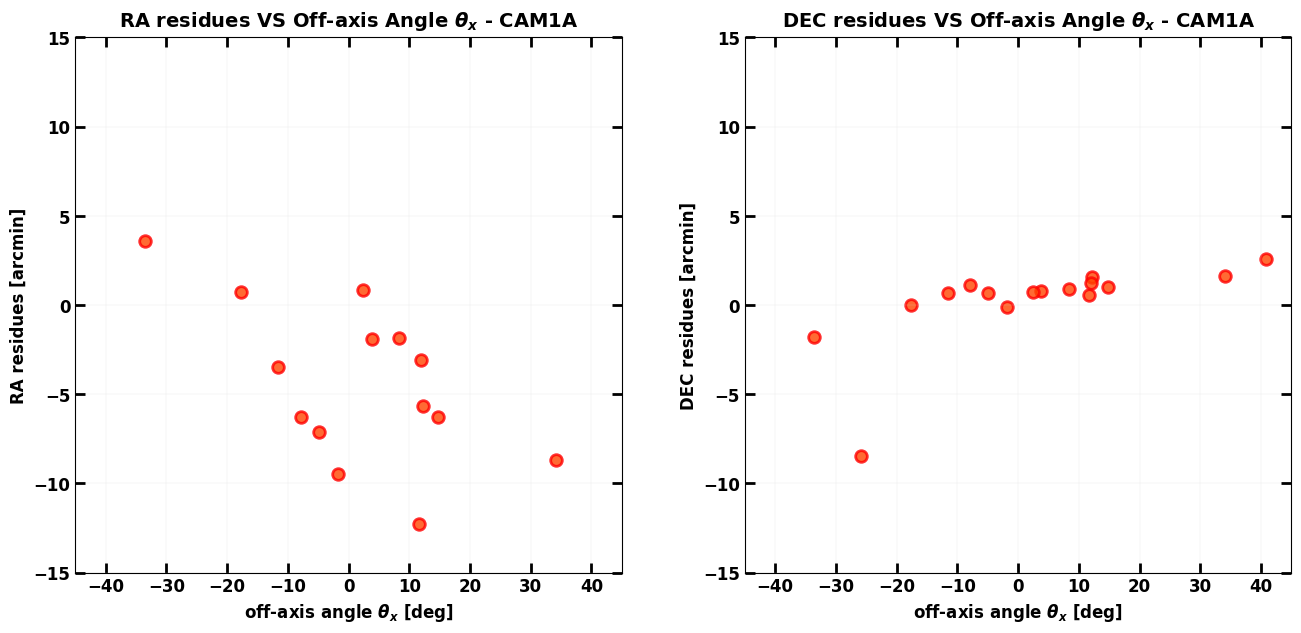

In [16]:
# CAM 1A
ra_res_cam1a = 60*res_df[cam_a]["ra_res"]
thetay_cam1a = database[cam_a]["theta_y"]["data"]

dec_res_cam1a = 60*res_df[cam_a]["dec_res"]
thetax_cam1a = database[cam_a]["theta_x"]["data"]

thetay_cam1a = np.delete(thetay_cam1a, 13); thetax_cam1a = np.delete(thetax_cam1a, 13)


offsetx=[(-45, 45)]*2
offsety=[(-15, 15)]*2

iros.plot_sequence(
    input_sequence=[ra_res_cam1a, dec_res_cam1a],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1A", r"DEC residues VS Off-axis Angle $\theta_{y}$ - CAM1A"],
    x=[thetay_cam1a, thetay_cam1a],
    xlabel=[r"off-axis angle $\theta_{y}$" + " [deg]", r"off-axis angle $\theta_{y}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)
iros.plot_sequence(
    input_sequence=[ra_res_cam1a, dec_res_cam1a],
    title=[r"RA residues VS Off-axis Angle $\theta_{x}$ - CAM1A", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1A"],
    x=[thetax_cam1a, thetax_cam1a],
    xlabel=[r"off-axis angle $\theta_{x}$" + " [deg]", r"off-axis angle $\theta_{x}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)

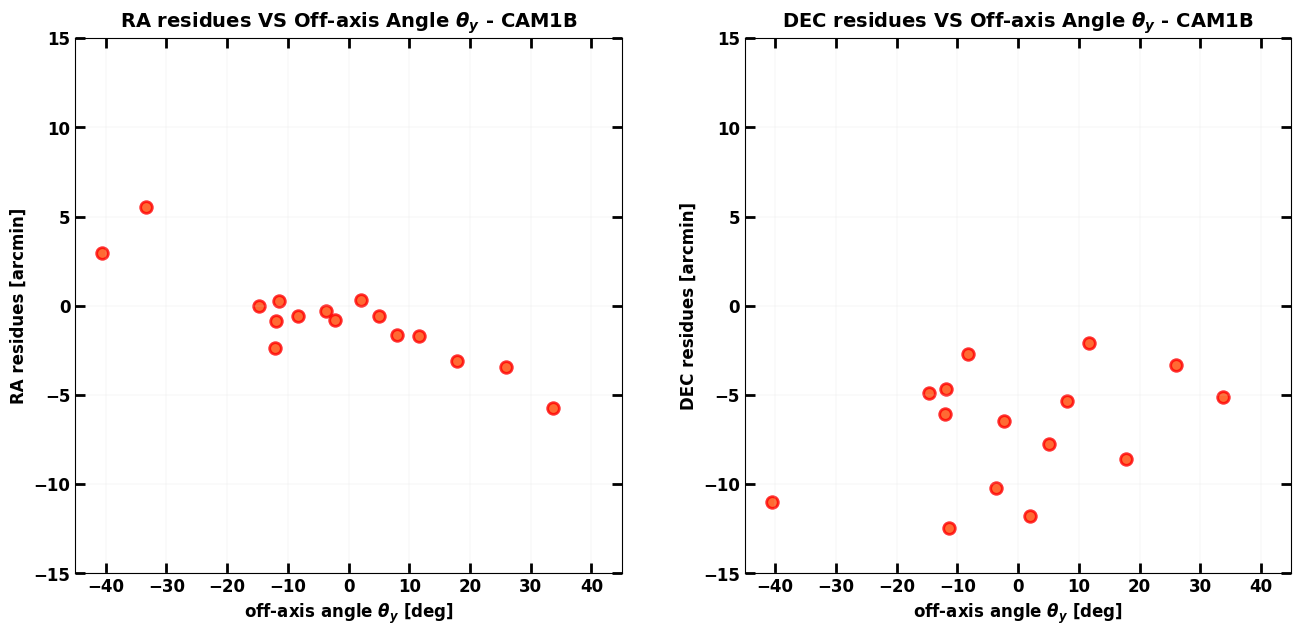

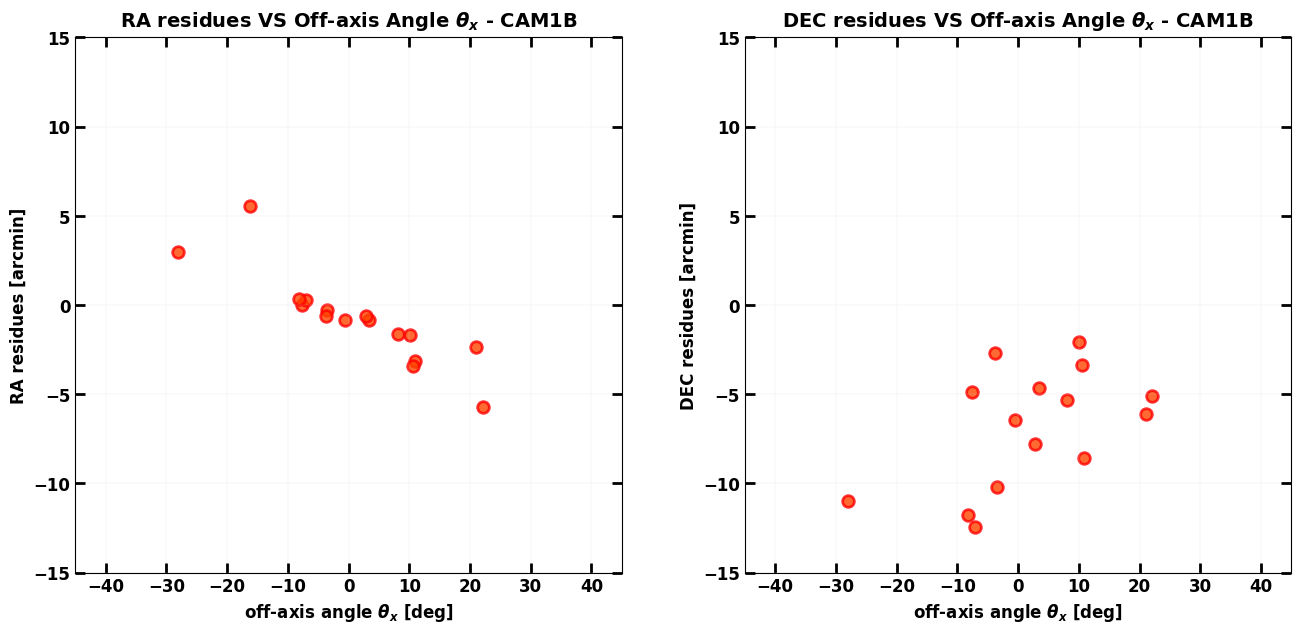

In [17]:
# CAM 1B
ra_res_cam1b = 60*res_df[cam_b]["ra_res"]
thetay_cam1b = database[cam_b]["theta_y"]["data"]

dec_res_cam1b = 60*res_df[cam_b]["dec_res"]
thetax_cam1b = database[cam_b]["theta_x"]["data"]

thetay_cam1b = np.delete(thetay_cam1b, 13); thetax_cam1b = np.delete(thetax_cam1b, 13)


offsetx=[(-45, 45)]*2
offsety=[(-15, 15)]*2

iros.plot_sequence(
    input_sequence=[ra_res_cam1b, dec_res_cam1b],
    title=[r"RA residues VS Off-axis Angle $\theta_{y}$ - CAM1B", r"DEC residues VS Off-axis Angle $\theta_{y}$ - CAM1B"],
    x=[thetay_cam1b, thetay_cam1b],
    xlabel=[r"off-axis angle $\theta_{y}$" + " [deg]", r"off-axis angle $\theta_{y}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)
iros.plot_sequence(
    input_sequence=[ra_res_cam1b, dec_res_cam1b],
    title=[r"RA residues VS Off-axis Angle $\theta_{x}$ - CAM1B", r"DEC residues VS Off-axis Angle $\theta_{x}$ - CAM1B"],
    x=[thetax_cam1b, thetax_cam1b],
    xlabel=[r"off-axis angle $\theta_{x}$" + " [deg]", r"off-axis angle $\theta_{x}$" + " [deg]"],
    ylabel=["RA residues [arcmin]", "DEC residues [arcmin]"],
    style=["scatter"]*2,
    offsetx=offsetx,
    offsety=offsety,
)

- Histogram with RA/DEC residues between IROS and catalog sources

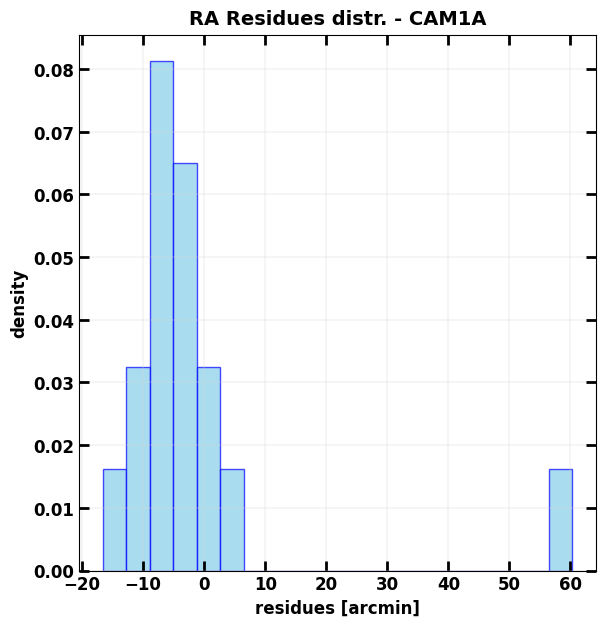

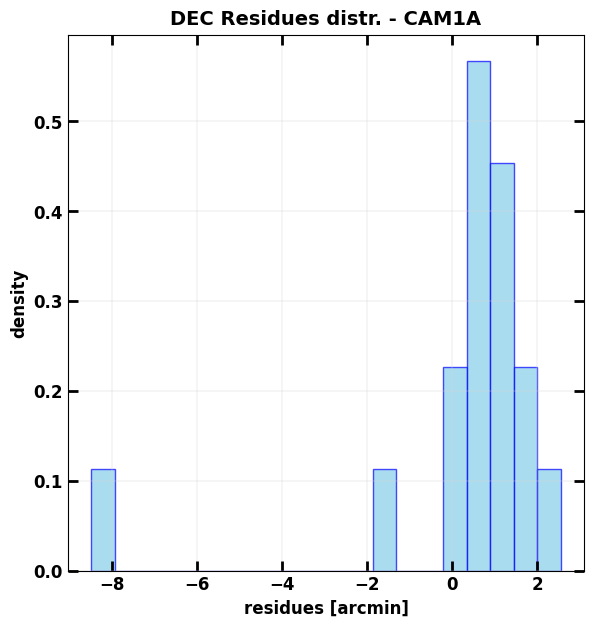

In [18]:
iros.plot_distr(
    arr=ra_res_cam1a,
    title=f"RA Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)
iros.plot_distr(
    arr=dec_res_cam1a,
    title=f"DEC Residues distr. - {cam_a.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)

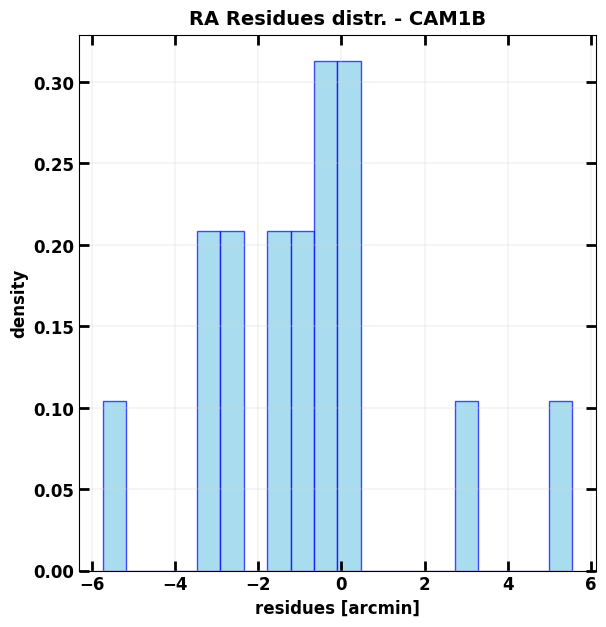

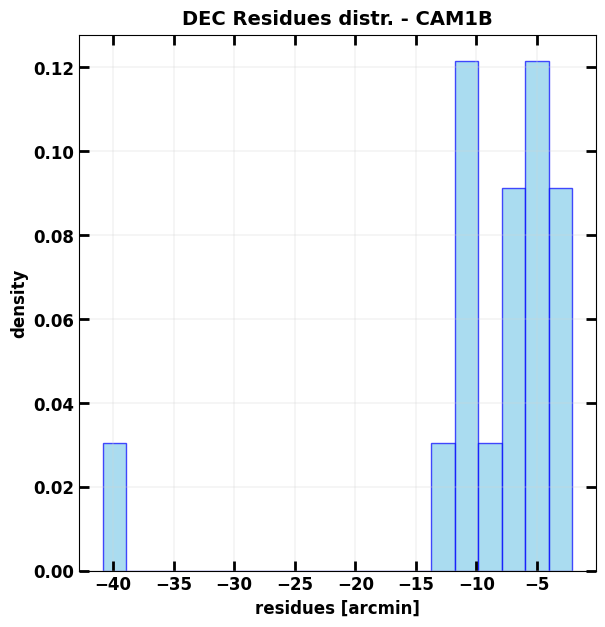

In [ ]:
iros.plot_distr(
    arr=ra_res_cam1b,
    title=f"RA Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)
iros.plot_distr(
    arr=dec_res_cam1b,
    title=f"DEC Residues distr. - {cam_b.upper()}",
    bins=20,
    xlabel="residues [arcmin]",
)

- Histogram with angular separation between IROS and catalog sources

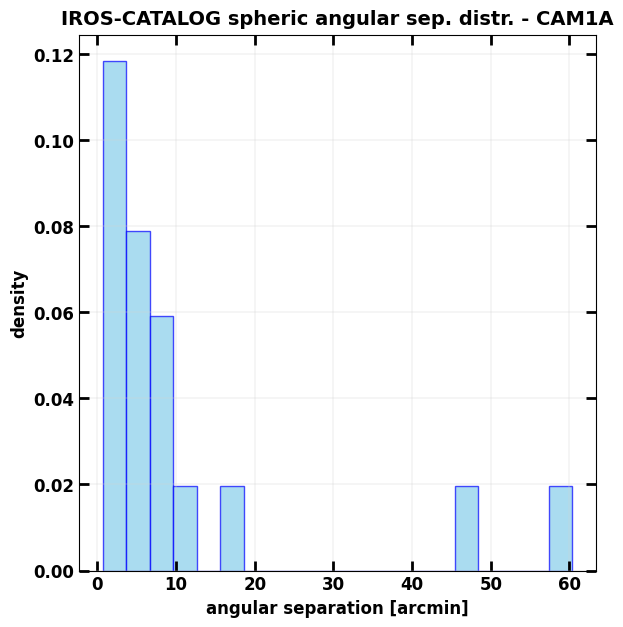

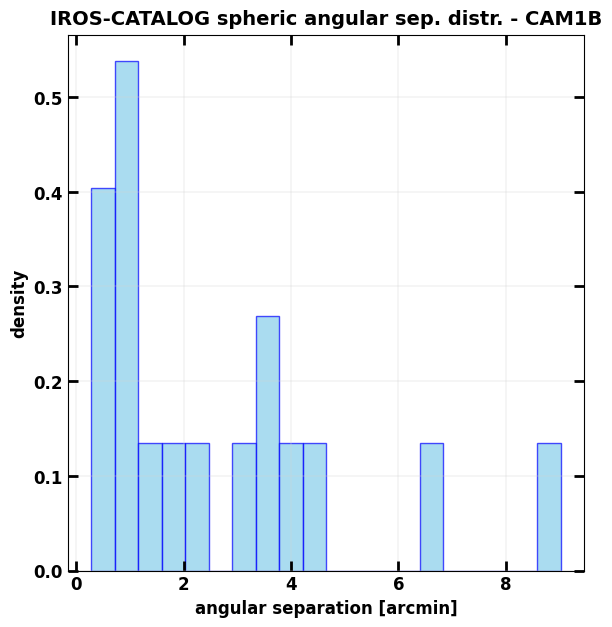

In [19]:
import astropy.units as u
from astropy.coordinates import Angle
from astropy.coordinates.angles.utils import angular_separation

ang_sep_cam1a = []
ang_sep_cam1b = []


# careful here, `angular_separation` output is in [rad]
for cam, cat, ang_sep in zip(
    (cam_a, cam_b),
    (catalogA, catalogB),
    (ang_sep_cam1a, ang_sep_cam1b),
):
    for iros_dec, iros_ra, name in zip(
        database[cam]["dec"]["data"],
        database[cam]["ra"]["data"],
        database[cam]["catalog_name"]["data"],        
    ):
        cat_dec = cat.data[cat.data["NAME"] == name]["DEC"][0]
        cat_ra = cat.data[cat.data["NAME"] == name]["RA"][0]
        ang_sep.append(
            np.rad2deg(
                angular_separation(
                    Angle(iros_dec, unit=u.deg), Angle(iros_ra, unit=u.deg),
                    Angle(cat_dec, unit=u.deg), Angle(cat_ra, unit=u.deg),
                ).value,
            ),
        )


iros.plot_distr(
    arr=60*np.array(ang_sep_cam1a),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_a.upper()}",
    bins=20,
    xlabel="angular separation [arcmin]"
)

iros.plot_distr(
    arr=60*np.array(ang_sep_cam1b),
    title=f"IROS-CATALOG spheric angular sep. distr. - {cam_b.upper()}",
    bins=20,
    xlabel="angular separation [arcmin]"
)